<a href="https://colab.research.google.com/github/vijji5432/pharma_project/blob/main/Mana_Pharma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
#library installatin for accessing the data
pip install pubchempy

# The dataset link provided in the assignment was not directly accessible
# due to a 400 Client Error from the PubChem API. Therefore,Fetched the
# data using the `pubchempy` library by querying PubChem directly for the
# required compounds using their CID values.
# The CIDs used were: 2244 (Aspirin), 1983 (Paracetamol), 702 (Ethanol),
# 6322 (Guanidine Acetate), and 5957 (Adenosine Triphosphate - ATP).
# The properties retrieved for each compound included:
# - Molecular Weight
# - LogP (Partition Coefficient)
# - InChIKey
# - Canonical SMILES

In [8]:
from pubchempy import get_compounds

cids = [2244, 1983, 702, 6322, 5957]
compounds = get_compounds(cids, 'cid')

for compound in compounds:
    print(f"CID: {compound.cid}")
    print(f"Molecular Weight: {compound.molecular_weight}")
    print(f"LogP: {compound.xlogp}")
    print(f"InChIKey: {compound.inchikey}")
    print(f"Canonical SMILES: {compound.canonical_smiles}")
    print("-----")



CID: 2244
Molecular Weight: 180.16
LogP: 1.2
InChIKey: BSYNRYMUTXBXSQ-UHFFFAOYSA-N
Canonical SMILES: CC(=O)OC1=CC=CC=C1C(=O)O
-----
CID: 1983
Molecular Weight: 151.16
LogP: 0.5
InChIKey: RZVAJINKPMORJF-UHFFFAOYSA-N
Canonical SMILES: CC(=O)NC1=CC=C(C=C1)O
-----
CID: 702
Molecular Weight: 46.07
LogP: -0.1
InChIKey: LFQSCWFLJHTTHZ-UHFFFAOYSA-N
Canonical SMILES: CCO
-----
CID: 6322
Molecular Weight: 174.20
LogP: -4.2
InChIKey: ODKSFYDXXFIFQN-BYPYZUCNSA-N
Canonical SMILES: C(CC(C(=O)O)N)CN=C(N)N
-----
CID: 5957
Molecular Weight: 507.18
LogP: -5.7
InChIKey: ZKHQWZAMYRWXGA-KQYNXXCUSA-N
Canonical SMILES: C1=NC(=C2C(=N1)N(C=N2)C3C(C(C(O3)COP(=O)(O)OP(=O)(O)OP(=O)(O)O)O)O)N
-----


# Inspecting the Data
# Loaded the data into a pandas DataFrame to perform initial inspection.
# The columns are: CID, Molecular Weight, LogP, InChIKey, and Canonical SMILES.



In [9]:
import pandas as pd

data = {
    "CID": [compound.cid for compound in compounds],
    "MolecularWeight": [compound.molecular_weight for compound in compounds],
    "LogP": [compound.xlogp for compound in compounds],
    "InChIKey": [compound.inchikey for compound in compounds],
    "CanonicalSMILES": [compound.canonical_smiles for compound in compounds]
}

df = pd.DataFrame(data)
df


,CID,MolecularWeight,LogP,InChIKey,CanonicalSMILES
0,2244,180.16,1.2,BSYNRYMUTXBXSQ-UHFFFAOYSA-N,CC(=O)OC1=CC=CC=C1C(=O)O
1,1983,151.16,0.5,RZVAJINKPMORJF-UHFFFAOYSA-N,CC(=O)NC1=CC=C(C=C1)O
2,702,46.07,-0.1,LFQSCWFLJHTTHZ-UHFFFAOYSA-N,CCO
3,6322,174.20,-4.2,ODKSFYDXXFIFQN-BYPYZUCNSA-N,C(CC(C(=O)O)N)CN=C(N)N
4,5957,507.18,-5.7,ZKHQWZAMYRWXGA-KQYNXXCUSA-N,C1=NC(=C2C(=N1)N(C=N2)C3C(C(C(O3)COP(=O)(O)OP(...


#Verified the data types and checked for any missing values, and found that
# there were no missing values in the dataset.

In [10]:
print(df.info())
print(df.isnull().sum())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CID              5 non-null      int64  
 1   MolecularWeight  5 non-null      object 
 2   LogP             5 non-null      float64
 3   InChIKey         5 non-null      object 
 4   CanonicalSMILES  5 non-null      object 
dtypes: float64(1), int64(1), object(3)
memory usage: 332.0+ bytes
None
CID                0
MolecularWeight    0
LogP               0
InChIKey           0
CanonicalSMILES    0
dtype: int64


# Step 4: Visualization of Trends
# **Molecular Weight vs LogP**:


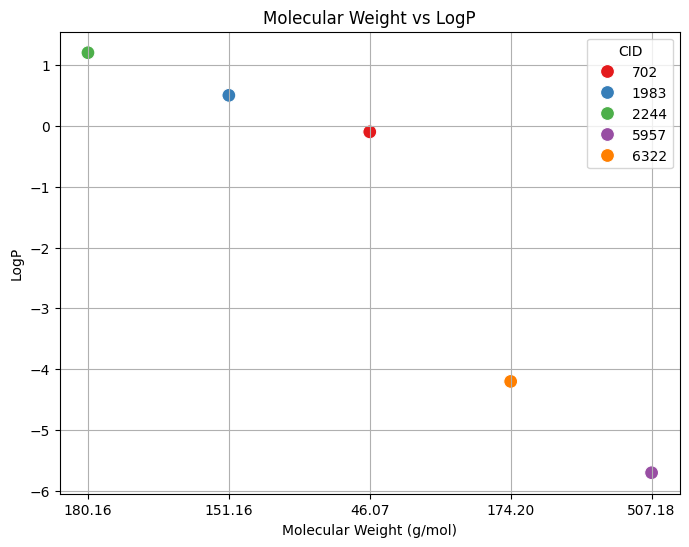

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="MolecularWeight", y="LogP", hue="CID", s=100, palette="Set1")
plt.title("Molecular Weight vs LogP")
plt.xlabel("Molecular Weight (g/mol)")
plt.ylabel("LogP")
plt.grid(True)
plt.show()


# **LogP vs Compound Name (CID)**:

<ipython-input-13-03fc8cbd33ba>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x="CID", y="LogP", palette="coolwarm")


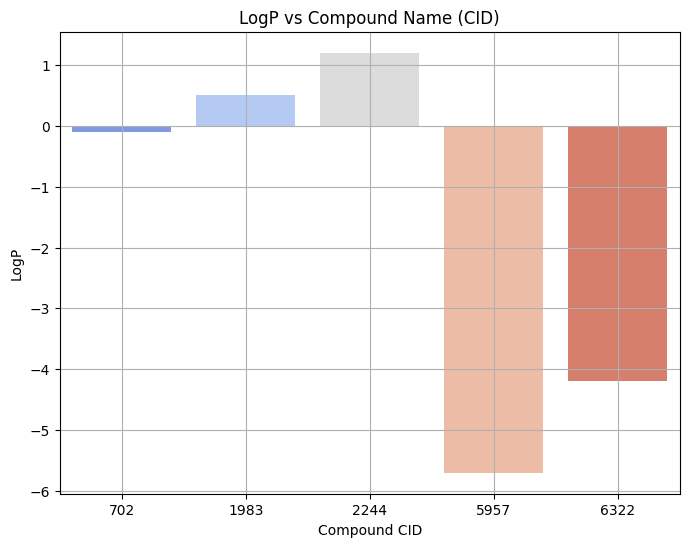

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a bar plot for LogP vs Compound (CID)
plt.figure(figsize=(8, 6))
sns.barplot(data=df, x="CID", y="LogP", palette="coolwarm")
plt.title("LogP vs Compound Name (CID)")
plt.xlabel("Compound CID")
plt.ylabel("LogP")
plt.grid(True)
plt.show()
